## Post-Hoc Recalibration of Prediction Intervals

Implements Kuleshov et al. (2018) recalibration to fix overcoverage.

**Split**: calibration (2001-2005) to learn the mapping, evaluation (2006-2009) to test it.

**Approach**: Learn a monotone (isotonic regression) mapping from predicted quantile levels
to empirical quantile levels on the calibration set, then apply to get corrected intervals
on the evaluation set.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('..')
import training_functions_freeze_uncertainty as training_functions
import importlib
importlib.reload(training_functions)

<module 'training_functions_freeze_uncertainty' from '/Users/paigepark/Desktop/repos/deep-mort/code_2026/tuning/../training_functions_freeze_uncertainty.py'>

### Load ensemble predictions and split into calibration / evaluation

In [17]:
# Load saved ensemble predictions (columns: geo, gender, year, age, mu, total_var,
#   aleatoric_var, epistemic_var, lower_95, upper_95)
ensemble_forecast = np.loadtxt('../../data/tuning_ensemble_forecast.txt')

# Load raw actuals for the full test period (2001-2010)
country_test = np.loadtxt('../../data/country_test.txt')

epsilon = 9e-06

# Split by year into calibration (2001-2005) and evaluation (2006-2010)
calib_mask = ensemble_forecast[:, 2] <= 2005
eval_mask = ensemble_forecast[:, 2] > 2005

ens_calib = ensemble_forecast[calib_mask]
ens_eval = ensemble_forecast[eval_mask]

actual_calib_mask = country_test[:, 2] <= 2005
actual_eval_mask = country_test[:, 2] > 2005

actual_calib = country_test[actual_calib_mask]
actual_eval = country_test[actual_eval_mask]

# Extract mu, std, and actual log-rates for each split
mu_calib = ens_calib[:, 4]
std_calib = np.sqrt(np.maximum(ens_calib[:, 5], 0))
actual_calib_log = np.log(np.maximum(actual_calib[:, 4], epsilon))

mu_eval = ens_eval[:, 4]
std_eval = np.sqrt(np.maximum(ens_eval[:, 5], 0))
actual_eval_log = np.log(np.maximum(actual_eval[:, 4], epsilon))

print(f'Calibration set: {len(mu_calib):,} rows (years {int(ens_calib[:, 2].min())}-{int(ens_calib[:, 2].max())})')
print(f'Evaluation set:  {len(mu_eval):,} rows (years {int(ens_eval[:, 2].min())}-{int(ens_eval[:, 2].max())})')
print(ensemble_forecast[1,:])

Calibration set: 40,000 rows (years 2001-2005)
Evaluation set:  32,000 rows (years 2006-2009)
[ 5.00000000e+01  1.00000000e+00  2.00100000e+03  0.00000000e+00
 -5.15463495e+00  1.11757278e-01  1.07397735e-01  4.36019897e-03
 -5.80986500e+00 -4.49940491e+00]


### Fit recalibration on calibration set

In [18]:
recal_model, predicted_ps, empirical_ps = training_functions.fit_recalibration(
    actual_calib_log, mu_calib, std_calib
)

print('Recalibration fit complete.')
print(f'Example: predicted 50th percentile has empirical coverage {empirical_ps[49]:.3f}')
print(f'Example: predicted 97.5th percentile has empirical coverage {empirical_ps[96]:.3f}')

Recalibration fit complete.
Example: predicted 50th percentile has empirical coverage 0.629
Example: predicted 97.5th percentile has empirical coverage 0.998


### Reliability diagram (calibration set)

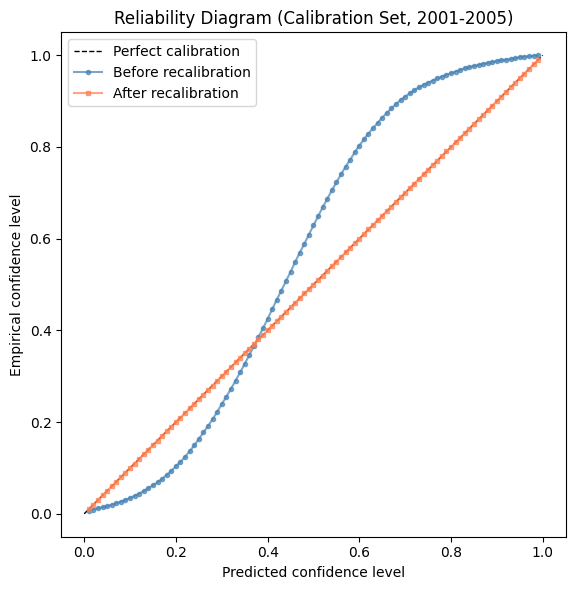

In [19]:
from scipy.stats import norm
from scipy.optimize import brentq

n_quantiles = 99
ps = np.linspace(1 / (n_quantiles + 1), n_quantiles / (n_quantiles + 1), n_quantiles)

# Before recalibration: empirical coverage at each predicted level
emp_before_calib = np.array([np.mean(actual_calib_log <= mu_calib + norm.ppf(p) * std_calib) for p in ps])

# After recalibration: invert recal_model to find nominal level q where recal_model(q) = p,
# then compute actual coverage using that corrected nominal level
recal_nominal_calib = np.array([
    brentq(lambda q: recal_model.predict([q])[0] - p, 0.001, 0.999)
    for p in ps
])
emp_after_calib = np.array([
    np.mean(actual_calib_log <= mu_calib + norm.ppf(q) * std_calib)
    for q in recal_nominal_calib
])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.plot(ps, emp_before_calib, 'o-', markersize=3, color='steelblue',
        label='Before recalibration', alpha=0.7)
ax.plot(ps, emp_after_calib, 's-', markersize=3, color='coral',
        label='After recalibration', alpha=0.7)
ax.set_xlabel('Predicted confidence level')
ax.set_ylabel('Empirical confidence level')
ax.set_title('Reliability Diagram (Calibration Set, 2001-2005)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Apply recalibration to evaluation set

In [21]:
# Original (uncalibrated) 95% intervals on evaluation set
orig_lower_eval = mu_eval - 1.96 * std_eval
orig_upper_eval = mu_eval + 1.96 * std_eval

# Recalibrated 95% intervals
recal_lower_eval, recal_upper_eval, z_lo, z_hi = training_functions.recalibrated_prediction_intervals(
    mu_eval, std_eval, recal_model, alpha=0.05
)

print(f'Original z-scores:      -1.960,  +1.960')
print(f'Recalibrated z-scores:  {z_lo:.3f},  {z_hi:+.3f}')

Original z-scores:      -1.960,  +1.960
Recalibrated z-scores:  -1.435,  +1.007


### Compare metrics: before vs after recalibration (evaluation set)

In [22]:
def coverage(actual, lower, upper):
    return np.mean((actual >= lower) & (actual <= upper))

def winkler_score(actual, lower, upper, alpha=0.05):
    width = upper - lower
    penalty = np.where(
        actual < lower,
        (2 / alpha) * (lower - actual),
        np.where(actual > upper, (2 / alpha) * (actual - upper), 0.0),
    )
    return width + penalty

def interval_width(lower, upper):
    return np.mean(upper - lower)

# Original
orig_cov = coverage(actual_eval_log, orig_lower_eval, orig_upper_eval)
orig_winkler = np.mean(winkler_score(actual_eval_log, orig_lower_eval, orig_upper_eval))
orig_width = interval_width(orig_lower_eval, orig_upper_eval)

# Recalibrated
recal_cov = coverage(actual_eval_log, recal_lower_eval, recal_upper_eval)
recal_winkler = np.mean(winkler_score(actual_eval_log, recal_lower_eval, recal_upper_eval))
recal_width = interval_width(recal_lower_eval, recal_upper_eval)

print(f'{"Metric":<25s}  {"Original":>12s}  {"Recalibrated":>12s}')
print(f'{"-"*25}  {"-"*12}  {"-"*12}')
print(f'{"95% Coverage (target .95)":<25s}  {orig_cov:>12.3f}  {recal_cov:>12.3f}')
print(f'{"Avg Interval Width":<25s}  {orig_width:>12.4f}  {recal_width:>12.4f}')
print(f'{"Mean Winkler Score":<25s}  {orig_winkler:>12.4f}  {recal_winkler:>12.4f}')

Metric                         Original  Recalibrated
-------------------------  ------------  ------------
95% Coverage (target .95)         0.980         0.932
Avg Interval Width               1.3874        0.8643
Mean Winkler Score               1.8239        1.8198


### Compare against coherent model (evaluation set only)

In [23]:
# Load coherent forecast and filter to evaluation years
coherent_forecast = np.genfromtxt('../../data/tuning_coherent_forecast.txt')

# Transform to log space (coherent outputs are in rate space)
coherent_forecast[:, 4] = np.log(coherent_forecast[:, 4])   # mu
coherent_forecast[:, 8] = np.log(coherent_forecast[:, 8])   # lower 95
coherent_forecast[:, 9] = np.log(coherent_forecast[:, 9])   # upper 95

# Filter to evaluation years (2006-2010)
coherent_eval_mask = coherent_forecast[:, 2] > 2005
coherent_eval = coherent_forecast[coherent_eval_mask]

# Align coherent with actual_eval on (geo, gender, year, age)
coherent_keys = set(map(tuple, coherent_eval[:, :4]))
actual_keys = set(map(tuple, actual_eval[:, :4]))
common_keys = coherent_keys & actual_keys

coherent_filtered = np.array([row for row in coherent_eval if tuple(row[:4]) in common_keys])
actual_filtered = np.array([row for row in actual_eval if tuple(row[:4]) in common_keys])

# Sort both by (geo, gender, year, age) so rows align
sort_idx = np.lexsort((coherent_filtered[:, 3], coherent_filtered[:, 2],
                        coherent_filtered[:, 1], coherent_filtered[:, 0]))
coherent_filtered = coherent_filtered[sort_idx]

sort_idx = np.lexsort((actual_filtered[:, 3], actual_filtered[:, 2],
                        actual_filtered[:, 1], actual_filtered[:, 0]))
actual_filtered = actual_filtered[sort_idx]

coherent_actual_log = np.log(np.maximum(actual_filtered[:, 4], epsilon))
coherent_mu = coherent_filtered[:, 4]
coherent_lower = coherent_filtered[:, 8]
coherent_upper = coherent_filtered[:, 9]

coh_cov = coverage(coherent_actual_log, coherent_lower, coherent_upper)
coh_winkler = np.mean(winkler_score(coherent_actual_log, coherent_lower, coherent_upper))
coh_width = interval_width(coherent_lower, coherent_upper)

print(f'Evaluation set (2006-2010) comparison:')
print(f'')
print(f'{"Model":<25s}  {"Coverage":>10s}  {"Width":>10s}  {"Winkler":>10s}')
print(f'{"-"*25}  {"-"*10}  {"-"*10}  {"-"*10}')
print(f'{"DL Original":<25s}  {orig_cov:>10.3f}  {orig_width:>10.4f}  {orig_winkler:>10.4f}')
print(f'{"DL Recalibrated":<25s}  {recal_cov:>10.3f}  {recal_width:>10.4f}  {recal_winkler:>10.4f}')
print(f'{"Coherent":<25s}  {coh_cov:>10.3f}  {coh_width:>10.4f}  {coh_winkler:>10.4f}')

Evaluation set (2006-2010) comparison:

Model                        Coverage       Width     Winkler
-------------------------  ----------  ----------  ----------
DL Original                     0.980      1.3874      1.8239
DL Recalibrated                 0.932      0.8643      1.8198
Coherent                        0.828      0.9830      1.9065


### Reliability diagram on evaluation set (the real test)

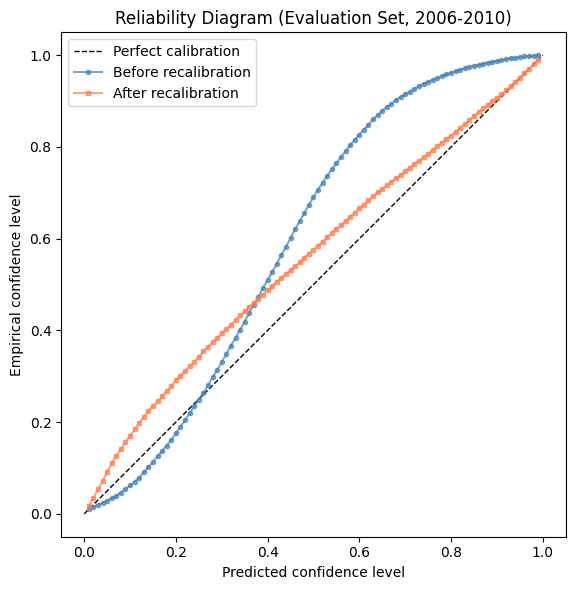

In [24]:
from scipy.stats import norm
from scipy.optimize import brentq

n_quantiles = 99
ps = np.linspace(1 / (n_quantiles + 1), n_quantiles / (n_quantiles + 1), n_quantiles)

# Before recalibration: empirical coverage at each predicted level
emp_before = np.array([np.mean(actual_eval_log <= mu_eval + norm.ppf(p) * std_eval) for p in ps])

# After recalibration: invert recal_model to find nominal level q where recal_model(q) = p,
# then compute actual coverage on the evaluation set
recal_nominal_eval = np.array([
    brentq(lambda q: recal_model.predict([q])[0] - p, 0.001, 0.999)
    for p in ps
])
emp_after = np.array([
    np.mean(actual_eval_log <= mu_eval + norm.ppf(q) * std_eval)
    for q in recal_nominal_eval
])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.plot(ps, emp_before, 'o-', markersize=3, color='steelblue',
        label='Before recalibration', alpha=0.7)
ax.plot(ps, emp_after, 's-', markersize=3, color='coral',
        label='After recalibration', alpha=0.7)
ax.set_xlabel('Predicted confidence level')
ax.set_ylabel('Empirical confidence level')
ax.set_title('Reliability Diagram (Evaluation Set, 2006-2010)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Coverage by age group (evaluation set)

Age     0  |  Original: 0.897  |  Recalibrated: 0.791
Age   1-4  |  Original: 0.926  |  Recalibrated: 0.834
Age  5-14  |  Original: 0.954  |  Recalibrated: 0.882
Age 15-24  |  Original: 0.956  |  Recalibrated: 0.877
Age 25-44  |  Original: 0.977  |  Recalibrated: 0.919
Age 45-64  |  Original: 0.997  |  Recalibrated: 0.975
Age 65-84  |  Original: 0.998  |  Recalibrated: 0.961
Age   85+  |  Original: 0.993  |  Recalibrated: 0.962


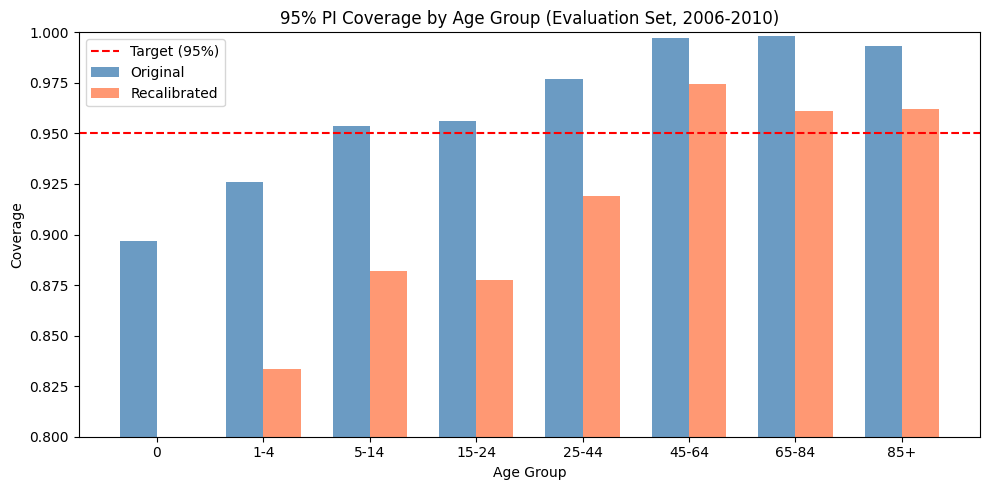

In [26]:
age_bins = [(0, 1), (1, 5), (5, 15), (15, 25), (25, 45), (45, 65), (65, 85), (85, 100)]
age_labels = ['0', '1-4', '5-14', '15-24', '25-44', '45-64', '65-84', '85+']

ages_eval = ens_eval[:, 3]

orig_covs = []
recal_covs = []

for (lo, hi), label in zip(age_bins, age_labels):
    if lo == 85:
        mask = ages_eval >= lo
    else:
        mask = (ages_eval >= lo) & (ages_eval < hi)

    oc = coverage(actual_eval_log[mask], orig_lower_eval[mask], orig_upper_eval[mask])
    rc = coverage(actual_eval_log[mask], recal_lower_eval[mask], recal_upper_eval[mask])
    orig_covs.append(oc)
    recal_covs.append(rc)
    print(f'Age {label:>5s}  |  Original: {oc:.3f}  |  Recalibrated: {rc:.3f}')

x = np.arange(len(age_labels))
width_bar = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width_bar/2, orig_covs, width_bar, label='Original', color='steelblue', alpha=0.8)
ax.bar(x + width_bar/2, recal_covs, width_bar, label='Recalibrated', color='coral', alpha=0.8)
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='Target (95%)')
ax.set_xticks(x)
ax.set_xticklabels(age_labels)
ax.set_ylabel('Coverage')
ax.set_xlabel('Age Group')
ax.set_title('95% PI Coverage by Age Group (Evaluation Set, 2006-2010)')
ax.set_ylim(0.8, 1.0)
ax.legend()
plt.tight_layout()
plt.show()